# Netflix Movies and TV Shows - Data Cleaning and Exploratory Analysis

**AI & ML Internship Track - Week 1**

**Goal:** Load a raw Netflix catalog dataset, identify what is wrong with it (missing values,
duplicates, incorrect data types), clean it with clear reasoning, then explore it with summary
statistics and visualizations.

**Dataset source:** 
[Netflix Movies and TV Shows Dataset](https://www.kaggle.com/datasets/sunil123kumar/netflix-movies-and-tv-shows-dataset) from Kaggle.

## Step 1: Importing necessary libraries

These libraries are used for data manipulation and visualization.   
- `Pandas` is used for data manipulation.
- `Matplotlib` and `Seaborn` are used for data visualization.



In [1]:

#This line imports the pandas library and gives it the alias pd
import pandas as pd 

#This line imports the matplotlib.pyplot library and gives it the alias plt
import matplotlib.pyplot as plt

#This line imports the seaborn library and gives it the alias sns
import seaborn as sns

#The following line is used to set the style of the plots
sns.set_style("whitegrid")

## Step 2: Load Dataset 


In [2]:
# This line reads the CSV file into a pandas DataFrame called df
df = pd.read_csv("netflix_titles.csv") 

# This line displays the first 5 rows of the DataFrame
df.head() 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Shapes tell us the number of rows and columns in the DataFrame.
print("Shape (rows, columns):", df.shape)

# This line provides a concise summary of the DataFrame, including the data types and non-null values.
df.info()

Shape (rows, columns): (8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


## Step 3: Identify missing values and duplicate rows
This is the diagnostic step - we look for problems before fixing them 

In [4]:
#missing values per column ,sorted form most to least
missing_values = df.isnull().sum().sort_values(ascending = False)
print("Missing values per column:")
print(missing_values[missing_values > 0])

print("\nNo of duplicate rows:", df.duplicated().sum())

Missing values per column:
director      2634
country        831
cast           825
date_added      10
rating           4
duration         3
dtype: int64

No of duplicate rows: 0


## Setp 4: Clean the data 

**My cleaning plan and why:** 
- `director`, `cast`, `country`: these are text columns where a missing value usually just means
  "not credited" or "not specified" rather than an error. I fill these with `"Unknown"` instead of
  dropping the rows, because dropping would throw away a large amount of otherwise-good data
  (title, type, rating, etc. are still valid for those rows).
- `rating`, `date_added`, `duration`: these have very few missing values, so I drop just those
  rows rather than inventing a value, since guessing a rating or duration could be misleading.
- Duplicate rows are removed completely, since a duplicate row adds no new information and
  would bias any counts or statistics.

In [5]:
#Fill text column with 'Unknown' for missing values
for col in ['director', 'cast', 'country']:
    df[col].fillna('Unknown', inplace=True)

#Drop rows with missing values in 'date_added','rating' and 'duration' columns
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

# Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Rows removed due to duplicates: {before - after}")

print("\nRemaining missing values :")
print(df.isnull().sum())


Rows removed due to duplicates: 0

Remaining missing values :
show_id            0
type               0
title              0
director        2621
cast             825
country          829
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64


C:\Users\Mansi\AppData\Local\Temp\ipykernel_9568\3507096691.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna('Unknown', inplace=True)


## Step 5: Fix data types

`date_added` is normally stored as text. I convert it to an actual date type so we can work
with years and months properly (for example, to see how content added to Netflix has grown
over time).

In [6]:
if "date_added" in df.columns:
    # Convert 'date_added' to datetime format
    df['date_added'] = pd.to_datetime(df['date_added'], format = 'mixed')

    # Extract year and month from 'date_added'
    df['year_added'] = df['date_added'].dt.year
    df['month_added'] = df['date_added'].dt.month

## Step 6: Summary Statistics

In [7]:
#Statistic 1: How many movies and TV shows are available on Netflix?
# Count the number of movies and TV shows
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [8]:
#Statistic 2: Mean and median release year of movies and TV shows
# Calculate mean and median release year for movies
print("Mean release year of movies:", df['release_year'].mean())
print("Median release year of movies:", df['release_year'].median())

Mean release year of movies: 2014.183162684869
Median release year of movies: 2017.0


In [9]:
#Statistic 3: Top 10 countries with the most content on Netflix
# Count the number of titles per country
df['country'].value_counts().head(10)

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

## Step 7: Visualizations

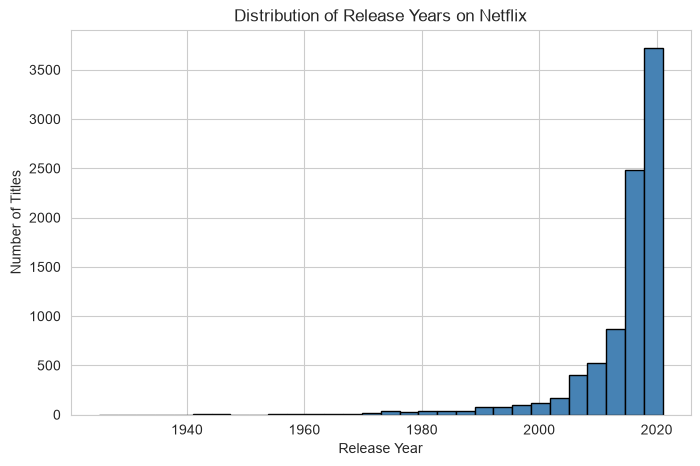

In [ ]:
#Chart 1: Histogram  - Distribution of release years for movies and TV shows
plt.figure(figsize=(8,5))
df['release_year'].hist(bins= 30,color = 'skyblue',edgecolor = 'black')
plt.title('Distribution of Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

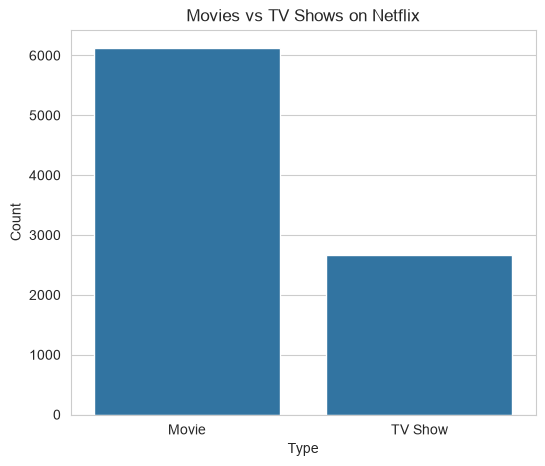

In [ ]:
#Chart 2 : Bar chart - Count of movies vs TV shows
plt.figure(figsize=(6,5))
sns.countplot(x = 'type' ,data = 'df')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()